In [ ]:
import s3fs
import xarray as xr
import ujson
import dask
import math
import numpy as np
from xmitgcm import llcreader
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import xrft
import metpy
from scipy.special import jn, yn
from metpy.cbook import example_data
from dask.diagnostics import ProgressBar
from xmitgcm import open_mdsdataset
from xgcm.grid import Grid
import numpy_groupies
import scipy as sc
from scipy.interpolate import interp1d
from scipy.spatial.distance import pdist
import metpy.calc as mpcalc                             
from metpy.units import units
from xarray.core.combine import _nested_combine
from functools import partial
import matplotlib.patches as patches
import random
from scipy.signal.windows import dpss
from functools import reduce
import operator
import scipy.special as sp
from scipy.optimize import least_squares
from dask import delayed, compute
from itertools import combinations
from scipy.integrate import simpson

def _multi_file_closer(closers):
    for closer in closers:
        closer()

In [2]:
endpoint_url = 'https://mghp.osn.xsede.org'
fs = s3fs.S3FileSystem(anon=True,
    client_kwargs={'endpoint_url': endpoint_url}
)


filelist = ['cnh-bucket-1/llc_surf/kerchunk_files/llc4320_Eta-U-V-W-Theta-Salt_f' + 
            str(var1) + '_k0_iter_' + str(var) + '.json' for var1 in range(10,11) for var in np.arange(10368,1496448,144*24)]
##144=1HR
#### 10368-1099008  1496448
mapper = [fs.open(file, mode='rb') for file in filelist]


reflist = [ujson.load(mapper1)for mapper1 in mapper]

open_ = dask.delayed(xr.open_dataset)
getattr_ = dask.delayed(getattr)

dict_list = [{"storage_options": {"fo": p,"remote_protocol": "s3",
    "remote_options": {"client_kwargs":{'endpoint_url': endpoint_url}, "anon": True}},"consolidated": False} for p in reflist]
datasets = [open_("reference://",engine="zarr",backend_kwargs=p,chunks={'i':720, 'j':720}) for p in dict_list]
closers = [getattr_(ds, "_close") for ds in datasets]
datasets, closers = dask.compute(datasets, closers)


ds = xr.combine_by_coords([dataset for dataset in datasets],compat="override", coords='minimal', combine_attrs='override')


for ds1 in datasets:
            ds1.close()

ds.set_close(partial(_multi_file_closer, closers))

In [3]:
endpoint_url = 'https://mghp.osn.xsede.org'
fs = s3fs.S3FileSystem(anon=True,
    client_kwargs={'endpoint_url': endpoint_url}
)

#mapper = fs.open('cnh-bucket-1/csjones/temp/replaced_fields.json', mode='rb')
#filelist = ['cnh-bucket-1/llc_surf/kerchunk_files/llc4320_Eta-U-V-W-Theta-Salt_f' + str(var1) + '_k0_iter_' + str(var) + '.json' for var1 in range(0,13) for var in np.arange(10368,10657,144)]
filelist = ['cnh-bucket-1/llc_surf/kerchunk_files/llc4320_grid_f' + str(var1) + '.json' for var1 in range(0,13)]
#filelist = filelist1 + filelist2

mapper = [fs.open(file, mode='rb') for file in filelist]


reflist = [ujson.load(mapper1)for mapper1 in mapper]

open_ = dask.delayed(xr.open_dataset)
getattr_ = dask.delayed(getattr)

dict_list = [{"storage_options": {"fo": p,"remote_protocol": "s3",
    "remote_options": {"client_kwargs":{'endpoint_url': endpoint_url}, "anon": True}},"consolidated": False} for p in reflist]
datasets = [open_("reference://",engine="zarr",backend_kwargs=p,chunks={}) for p in dict_list]
closers = [getattr_(ds, "_close") for ds in datasets]
datasets, closers = dask.compute(datasets, closers)


co = xr.combine_by_coords([dataset for dataset in datasets],compat="override", coords='minimal', combine_attrs='override')


for ds1 in datasets:
            ds1.close()

co.set_close(partial(_multi_file_closer, closers))

In [7]:
##################### Time slice #################
dataset=ds.groupby('time.month')
data = dataset[8].isel(time=[0, 6, 12, 18, 24])#.mean(dim='time', keepdims=True)
time=data['time']
u=data['U']
v=data['V']
time.values

array(['2012-08-01T00:00:00.000000000', '2012-08-07T00:00:00.000000000',
       '2012-08-13T00:00:00.000000000', '2012-08-19T00:00:00.000000000',
       '2012-08-25T00:00:00.000000000'], dtype='datetime64[ns]')

In [8]:
#################### INTERPOLATION ####################
grid = Grid(data)
u_interp = grid.interp(u, axis="X")
v_interp = grid.interp(v, axis="Y")

/vortex1/jupyter-ayantika36/.conda/envs/MITgcm/lib/python3.9/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/vortex1/jupyter-ayantika36/.conda/envs/MITgcm/lib/python3.9/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


In [9]:
################### MERGING LAT & LON #######
X=co['XC'][10,:,:]
Y=co['YC'][10,:,:]

u_merged= xr.merge([u_interp, X.rename("lon"),Y.rename("lat")])
v_merged= xr.merge([v_interp, X.rename("lon"),Y.rename("lat")])

In [10]:
######## REMOVAL OF LINEAR SPATIAL TREND ########
u_i_fit=u_merged.mean('j').polyfit('i',1)
u_i_val=xr.polyval(u_merged.i, u_i_fit.U_polyfit_coefficients)
#u_i_detrend.isel(time=0).plot()
u_i_detrend= u_merged.U - u_i_val

u_j_fit=u_merged.mean('i').polyfit('j',1)
u_j_val=xr.polyval(u_merged.j, u_j_fit.U_polyfit_coefficients)
#u_j_detrend.isel(time=0).plot()
u_detrend= u_i_detrend - u_j_val

v_i_fit=v_merged.mean('j').polyfit('i',1)
v_i_val=xr.polyval(v_merged.i, v_i_fit.V_polyfit_coefficients)
v_i_detrend= v_merged.V - v_i_val

v_j_fit=v_merged.mean('i').polyfit('j',1)
v_j_val=xr.polyval(v_merged.j, v_j_fit.V_polyfit_coefficients)
v_detrend= v_i_detrend - v_j_val

#print(v_detrend)
#print(u_interp)

#print(df_u)

ds_u= u_merged.assign(U = u_detrend)
ds_v= v_merged.assign(V= v_detrend)
#ds_u

In [11]:
################# Sliceing of Data  ###################
# GoM
# uv = ds_u.isel(j=slice(1931,2131),i=slice(3579,3779), face = 0, k = 0)
# vv = ds_v.isel(j=slice(1931,2131),i=slice(3579,3779), face = 0, k = 0)

uv = ds_u.isel(j=slice(1830,2030),i=slice(3520,3720), face = 0, k = 0)
vv = ds_v.isel(j=slice(1830,2030),i=slice(3520,3720), face = 0, k = 0)

In [12]:
uvel = uv.U
vvel = vv.V
uvel.shape

(5, 200, 200)

In [13]:
nj, ni = uvel["j"].shape[0], uvel["i"].shape[0]
print((nj, ni) )

(200, 200)


In [15]:
import numpy as np
import xarray as xr
from scipy.signal.windows import tukey
import matplotlib.pyplot as plt

def hann_window_2d(nj, ni):
    #nj, ni = shape
    hann_j = tukey(nj)
    hann_i = tukey(ni)
    return np.outer(hann_j, hann_i)

def apply_hann_window(velocity):
    nj, ni = velocity["j"].shape[0], velocity["i"].shape[0]
    hann_2d = hann_window_2d(nj, ni)
    hann_2d_expanded = np.repeat(hann_2d[np.newaxis, :, :], len(time), axis=0)    
    vel_windowed = np.zeros_like(velocity)
    for i in range(0,len(time)):
        print(i)
        vel_win = (velocity[i,:,:]) *  hann_2d_expanded[i,:,:]
        mean_per_time = np.nanmean(vel_win)
        vel_windowed[i,:,:] = vel_win -  mean_per_time
    return vel_windowed

# Apply Hann windowing
uvel_windowed= apply_hann_window(uvel)
vvel_windowed = apply_hann_window(vvel)

0
1
2
3
4
0
1
2
3
4


In [17]:
XC = uvel.XC
YC = vvel.YC

def compute_dx_dy_from_latlon(XC, YC):
    """
    Compute mean dx and dy (in meters) using np.gradient over lat-lon grids.
    XC, YC: xarray DataArrays or numpy arrays in degrees (shape: j, i)
    Returns: dx_mean, dy_mean in meters
    """
    R = 6371000  # Earth radius in meters
    deg2rad = np.pi / 180

    lat_rad = np.deg2rad(YC)
    print(lat_rad)
    # Grid spacing in degrees
    dlon = np.gradient(XC, axis=0)  
    dlat = np.gradient(YC, axis=1)
    
    # Convert to meters
    dx = R * np.cos(lat_rad) * deg2rad * dlon  # zonal spacing (j, i)
    dy = R * deg2rad * dlat                    # meridional spacing (j, i)
#     print(dx) 
    # Return mean absolute spacing
    dx_mean = np.abs(dx).mean().item()
    dy_mean = np.abs(dy).mean().item()
    return dx_mean, dy_mean


# Get dx and dy from coordinate grids
dx, dy = compute_dx_dy_from_latlon(XC.values,YC.values)
dx,dy

[[0.48874283 0.48844758 0.4881523  ... 0.42972562 0.42942175 0.42911783]
 [0.48874283 0.48844758 0.4881523  ... 0.42972562 0.42942175 0.42911783]
 [0.48874283 0.48844758 0.4881523  ... 0.42972562 0.42942175 0.42911783]
 ...
 [0.48874283 0.48844758 0.4881523  ... 0.42972562 0.42942175 0.42911783]
 [0.48874283 0.48844758 0.4881523  ... 0.42972562 0.42942175 0.42911783]
 [0.48874283 0.48844758 0.4881523  ... 0.42972562 0.42942175 0.42911783]]


(2076.403451305795, 1908.8968505859375)

In [18]:
def power_spectrum(uvel_windowed, dx, dy):
    time_steps, nj, ni = uvel_windowed.shape
    power_spectra = []
    
    # Create wavenumber arrays
    kx = np.fft.fftfreq(ni, dx) 
    ky = np.fft.fftfreq(nj, dy) 
    k_x = np.fft.fftshift(kx)
    k_y = np.fft.fftshift(ky)
    kx, ky = np.meshgrid(k_x, k_y, indexing="ij")
    dkx = np.diff(k_x)[0]
    dky = np.diff(k_y)[0]
                       
    
#     norm_factor = ((dx * dy)/(ni * nj * dkx * dky ) )  # scaling for Parseval consistency
    norm_factor = 2/(dkx * dky *(ni*nj)**2)                   
    
    for t in range(time_steps):
        # Perform 2D FFT
        fft2 = np.fft.fft2(uvel_windowed[t,:,:], norm = None)
        
        # Compute power spectrum
        power = ((np.abs(fft2))**2)* norm_factor
        power_shifted = np.fft.fftshift(power)
        power_spectra.append(power_shifted)
    
    # Average power spectrum over time
    #power_spectrum_avg = np.mean(power_spectra, axis=0)
    
    return k_x, k_y, power_spectra


# Compute power spectrum using accurate dx, dy
kx, ky, power_spec_u = power_spectrum(uvel_windowed, dx, dy)
kx, ky, power_spec_v = power_spectrum(vvel_windowed, dx, dy)

In [19]:
power_spec = []
for i in range(0,len(time)):
    freq_spec = 0.5 * (power_spec_u[i]+ power_spec_v[i])
    power_spec.append(freq_spec)
    

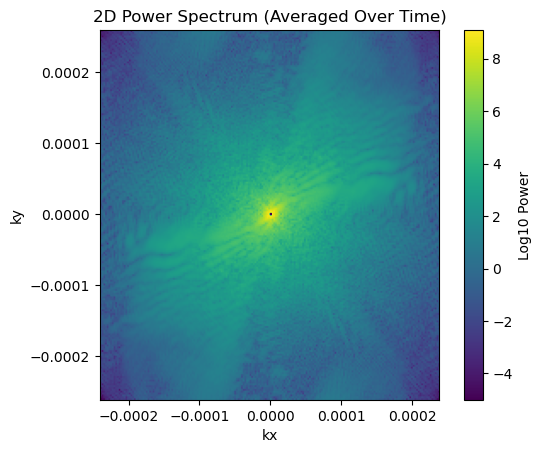

In [20]:
plt.title("2D Power Spectrum (Averaged Over Time)")
plt.imshow(np.log10(power_spec[0]), origin="lower", extent=(kx.min(), kx.max(), ky.min(), ky.max()),
           vmin=-5, cmap="viridis")
plt.colorbar(label="Log10 Power")
plt.xlabel("kx")
plt.ylabel("ky")
plt.show()

In [21]:
dkx = np.diff(np.sort(kx))   #[0]
dky = np.diff(np.unique(ky))   #[0]

def isotropic_spectrum(power_spec, kx, ky, N, nfactor):
    """
    Compute isotropic (azimuthally averaged) 1D energy spectral density from 2D power spectrum.

    Parameters:
        power_spec: 2D array of power spectrum (shifted)
        kx, ky: 1D arrays of fftshifted wavenumbers
        N: grid size reference
        nfactor: bin coarsening factor (nbins = N / nfactor)

    Returns:
        k_bins_center: 1D array of bin centers
        E_k: 1D array of isotropic energy spectral density
    """
    kx_grid, ky_grid = np.meshgrid(kx, ky, indexing="ij")
    k_grid = np.sqrt(kx_grid**2 + ky_grid**2)
    k_flat = k_grid.ravel()
    power_flat = power_spec.ravel()

    k_min = k_flat.min() #first non zero value np.sort(k_flat)[1] #
    k_max = k_flat.max()

    nbins = int(N / nfactor)
    k_bins = np.linspace(k_min, k_max, nbins + 1)
    k_bins_center = 0.5 * (k_bins[:-1] + k_bins[1:])
    dk = np.diff(k_bins)

    k_idx = np.digitize(k_flat, k_bins) - 1

    E_k = np.zeros(nbins)

    for i in range(nbins):
        bin_mask = (k_idx == i)
        n_points = np.sum(bin_mask)

        if n_points > 0 and k_bins_center[i] > 0:
            E_k[i] = np.mean(power_flat[bin_mask]) * k_bins_center[i] 
        else:
            E_k[i] = np.nan
    
    return k_bins_center, E_k


#Usage
N = np.shape(power_spec[0])[0] 
print(N)
nfactor = 1
PS = []
k_axis = []

for i in range(0,len(time)):
    k,ps = isotropic_spectrum(power_spec[i], kx, ky, N, nfactor)
    PS.append(ps)
    k_axis.append(k)

200


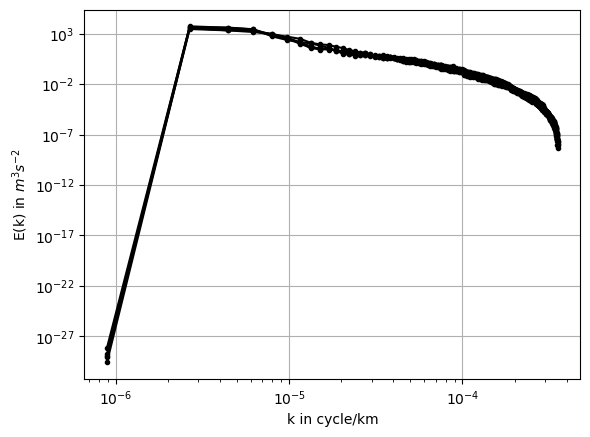

In [22]:
for i in range(0, len(time)):
    plt.plot(k_axis[i], PS[i], color = "black", marker = ".")
    plt.semilogx()
    plt.semilogy()
plt.xlabel('k in cycle/km')
plt.ylabel('E(k) in $m^3s^{-2}$')
# plt.title('Oct')
# plt.ylim(1e-9,1e5)
plt.grid()
# plt.legend()    

In [23]:
PS_mean = np.mean(PS, axis = 0)
k = k_axis[0]


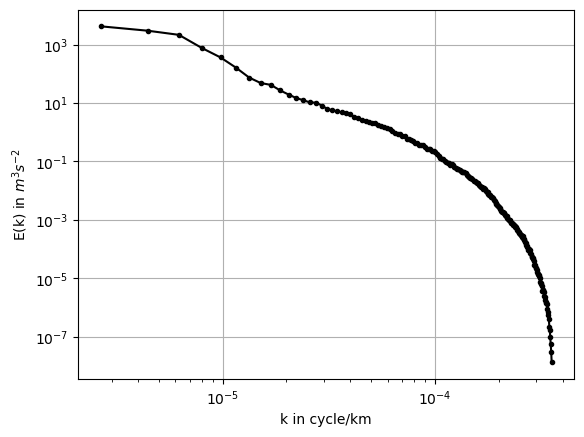

In [24]:
plt.plot(k[1::], PS_mean[1::], color = "black", marker = ".")
plt.semilogx()
plt.semilogy()
plt.xlabel('k in cycle/km')
plt.ylabel('E(k) in $m^3s^{-2}$')
plt.grid()

In [25]:
k_axis_chopped = []
PS_chopped = []
for i in range(0, len(time)):
    mask = k_axis[i] <= 2.5e-4
    k_new = k_axis[i][mask]
    PS_chopped.append(PS[i][mask])
    k_axis_chopped.append(k_new * 2 * np.pi )

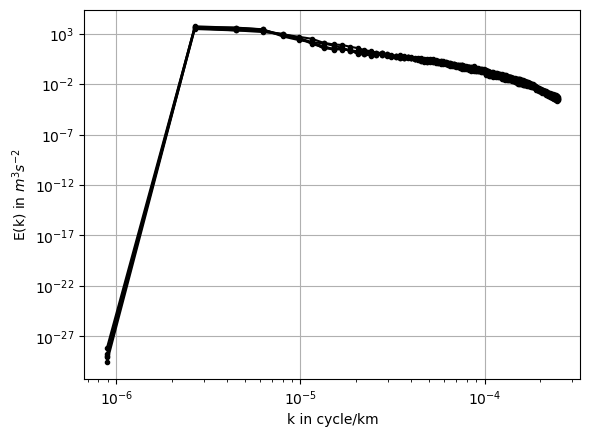

In [26]:
for i in range(0, len(time)):
    plt.plot(k_axis_chopped[i]/(2 * np.pi), PS_chopped[i], color = "black", marker = ".")
    plt.semilogx()
    plt.semilogy()
plt.xlabel('k in cycle/km')
plt.ylabel('E(k) in $m^3s^{-2}$')
# plt.title('Oct')
# plt.ylim(1e-9,1e5)
plt.grid()
# plt.legend()    

In [27]:
######## Simpson's method ########
def bessel_kernel(k,r): 
    return (sp.jv(0,k*r))


def sf2_from_Ek(r, k, Ek):
    """
    Compute SF2(r) = 2 ∫ E(k) [1 - J0(k r)] dk on a pre-defined k grid.
    r can be scalar or array. Returns array with shape (len(r),).
    """
    k = np.asarray(k, float)
    Ek = np.asarray(Ek, float)
    r = np.atleast_1d(r).astype(float)

    kk = k[:, None]            # (Nk, 1)
    rr = r[None, :]            # (1, Nr)

    kernel = 2.0 * (1.0 - bessel_kernel(kk, rr))   # (Nk, Nr)
    integrand = Ek[:, None] * kernel               # (Nk, Nr)

    sf2 = simpson(integrand, x=k, axis=0)          # integrate along k
    return sf2 if r.size > 1 else sf2.item()



In [28]:
k_i = k_axis_chopped[0] 
r_j = 2*np.pi/k_i[::-1]

SF2 = []
for i in range(0,len(time)):
    sf2 = sf2_from_Ek(r_j, k_i, PS_chopped[i]) #[1:] )
#     print(sf2)
    SF2.append(sf2)

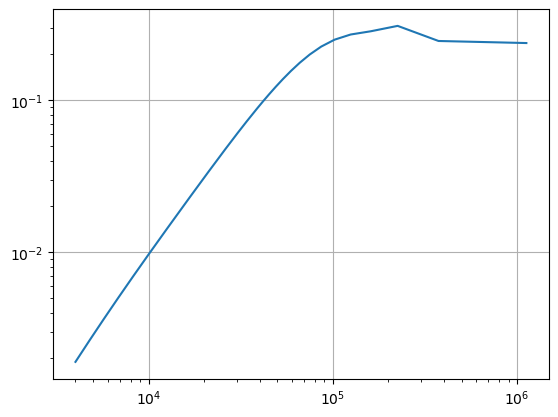

In [29]:
SF2_from_EK = np.mean(SF2,axis = 0)
plt.plot(r_j, SF2_from_EK)
plt.xscale("log")
plt.yscale("log")
plt.grid()

In [30]:
PS_chopped_mean = np.mean(PS_chopped, axis = 0)
k_chopped_mean = k_axis_chopped[0]

In [31]:
SF2_da = xr.DataArray(
    SF2_from_EK,
    dims=("r",),
    coords={"r": r_j},
    name="SF2_from_EK",
)

PS_da = xr.DataArray(
    PS_chopped_mean,
    dims=("k",),
    coords={"k": k_chopped_mean},
    name="PS_mean",
)

# Combine into one Dataset
ds_out = xr.Dataset({"SF2_from_EK": SF2_da, "PS_mean": PS_da})

# Save to netCDF
# ds_out.to_netcdf("domain_400km/ps_data/ps_jul.nc")
# ds_out.to_netcdf("domain_400km/chopped_ps_data/ps_aug.nc")


# print("Saved as Spectra_SF2_combined.nc")
print(ds_out)

<xarray.Dataset> Size: 5kB
Dimensions:      (r: 141, k: 141)
Coordinates:
  * r            (r) float64 1kB 4.001e+03 4.029e+03 ... 3.747e+05 1.124e+06
  * k            (k) float64 1kB 5.589e-06 1.677e-05 ... 0.001559 0.00157
Data variables:
    SF2_from_EK  (r) float64 1kB 0.001894 0.001919 0.001945 ... 0.2449 0.2374
    PS_mean      (k) float64 1kB 2.233e-29 4.196e+03 ... 0.0003938 0.000363
